In [1]:
from scipy.optimize import curve_fit
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os 
import sys

fontsize = 15

## 1. RC series circuit: temporal or transient response

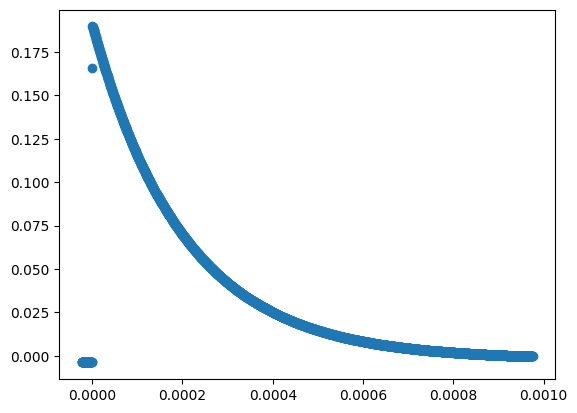

In [2]:
data1 = pd.read_csv('../data/scope_37.csv')[3:]
data1['x-axis'] = pd.to_numeric(data1['x-axis'], errors='coerce')
data1['2'] = pd.to_numeric(data1['2'], errors='coerce')
plt.scatter(data1['x-axis'], data1['2'])

0.19206586088094232 +- 1.1560134828025055e-05
0.0002027911522631586 +- 2.7731857601579525e-08
-0.0017443272128039968 +- 5.6608759176502495e-06


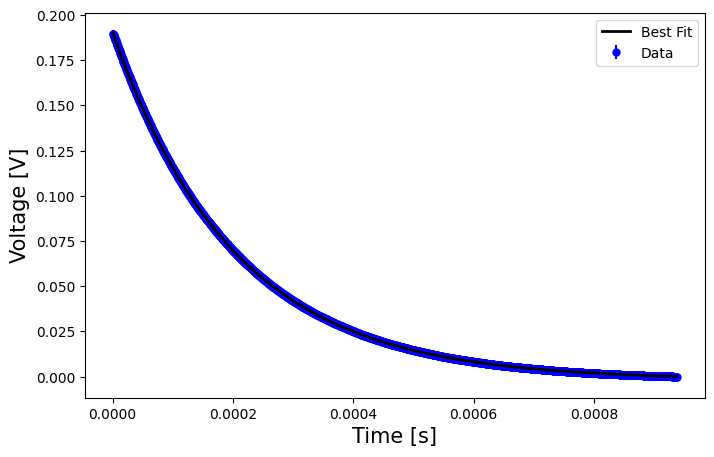

In [12]:
temp = data1.query('`x-axis` > 0.00 and `2` >0.00').copy()
x = temp['x-axis']
y = temp['2']

def model_func(x, A, tau, c):
    return A * np.exp(-x / tau) + c

popt, pcov = curve_fit(model_func, x, y, p0=[1, 1, 1])
a, k, b= popt
a_err, k_err, b_err = np.sqrt(np.diag(pcov))

print(f'{a} +- {a_err}')
print(f'{k} +- {k_err}')
print(f'{b} +- {b_err}')


fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    x, 
    y,
    fmt='o',
    markersize=5,
    label='Data',
    c='blue',
    yerr=0.002
)
ax.plot(
    x, 
    model_func(x, a, k, b),
    c='k',
    linewidth=2,
    zorder=15,
    label='Best Fit'
)
ax.legend()
ax.set_xlabel('Time [s]', fontsize=fontsize)
ax.set_ylabel('Voltage [V]', fontsize=fontsize)

plt.savefig('../tex/figures/part1_voltage_vs_time.png', bbox_inches='tight')

In [7]:
28 / 5/ 2 * 10**(-3)

0.0028

-154.47384584761903 0.11179096341837332


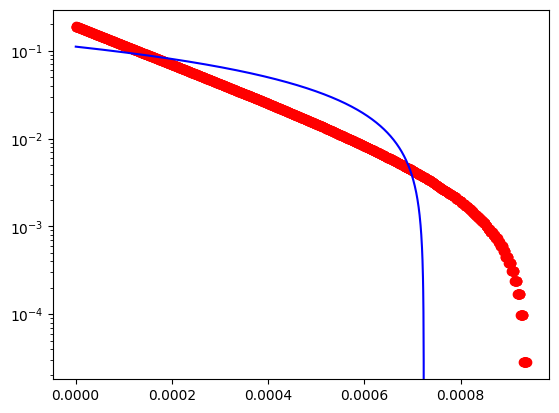

In [4]:
fig, ax = plt.subplots()
ax.scatter(
    temp['x-axis'],
    temp['2'],
    color='red'
)
ax.set_yscale('log')

m, b = np.polyfit(temp['x-axis'], temp['2'], 1)
y_fit = m * temp['x-axis'] + b

ax.plot(
    temp['x-axis'],
    y_fit,
    color='blue'
)
print(m, b)

# 2. RC series circuit: frequency response

In [13]:
data2 = pd.read_csv('../data/part-2-frequency-response.txt', delimiter='\t')
data2 = data2.sort_values(by='f (Hz)').reset_index(drop=True)
 
frequency = data2['f (Hz)']
freq_err = data2['df (Hz)']
gain = data2['gain']
gain_err = data2['dgain']
phase = data2['phase (degrees)']
phase_err = data2['dphase (degrees)']

## Gain vs Frequency

Text(0, 0.5, 'Gain')

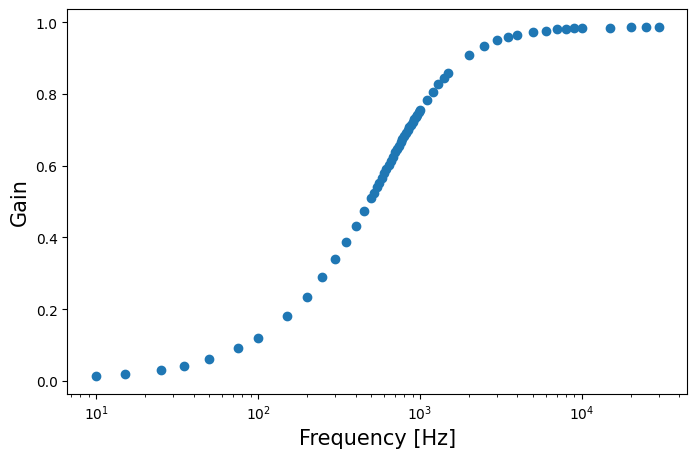

In [14]:
# (c)
plt.figure(figsize=(8, 5))
plt.errorbar(
    frequency, 
    gain,
    xerr=freq_err, 
    yerr=gain_err,
    fmt='o'
)
plt.xscale('log')
plt.xlabel('Frequency [Hz]', fontsize=fontsize)
plt.ylabel("Gain", fontsize=fontsize)

0.0001866870048109448
[6.71708331e-07]


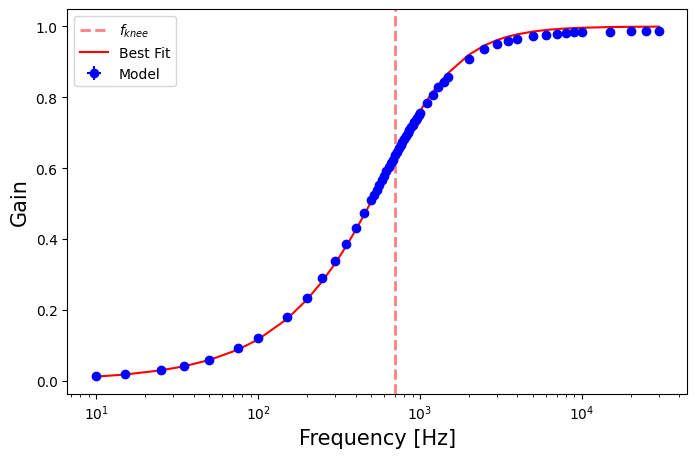

In [18]:
def gain_model_func(x, rc):
    return 2 * np.pi * x * rc / np.sqrt(1 + (2 * np.pi * x * rc)**2)

frequency = data2['f (Hz)']
gain = data2['gain']
popt, pcov = curve_fit(gain_model_func, frequency, gain)
print(*popt)
print(np.sqrt(np.diag(pcov)))


fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(
    frequency, 
    gain, 
    xerr=freq_err,
    yerr=gain_err,
    fmt='o', 
    label='Model',
    c='blue',
)
plt.axvline(699.9, color='red', linestyle='--', linewidth=2, alpha=.5, label=r'$f_{knee}$')
ax.plot(frequency, gain_model_func(frequency, *popt), 'r-', label='Best Fit')
ax.set_xscale('log')

ax.set_xlabel('Frequency [Hz]', fontsize=fontsize)
ax.set_ylabel('Gain', fontsize=fontsize)
ax.legend()
plt.savefig('../tex/figures/part2_gain_vs_freq.png', bbox_inches='tight')

## Phase vs Frequency

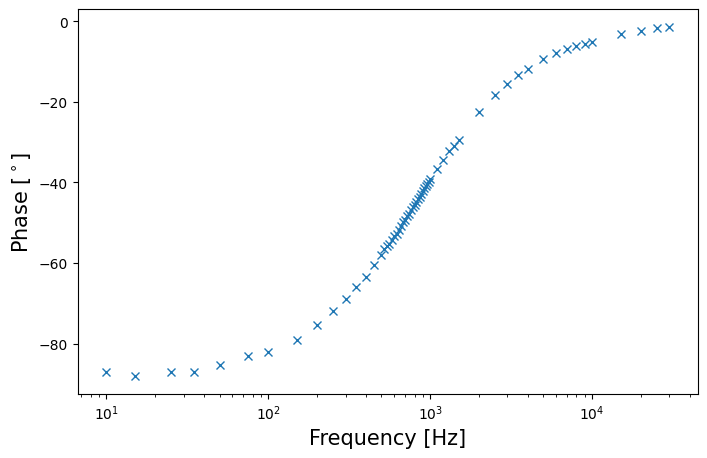

In [19]:
# (c)
plt.figure(figsize=(8, 5))
plt.errorbar(
    frequency, 
    phase, 
    xerr=freq_err,
    yerr=phase_err, 
    fmt='x'
)
plt.xscale('log')
plt.xlabel('Frequency [Hz]', fontsize=fontsize)
plt.ylabel(r'Phase [$^\circ$]', fontsize=fontsize)
plt.show()

[0.00019621]
[7.05281529e-07]


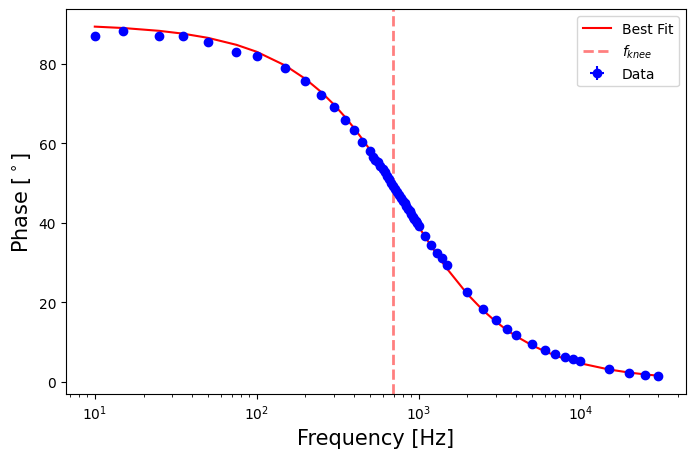

In [ ]:
np.radians(phase)

def phase_model_func(x, rc):
    return np.degrees(np.arctan(1 / (2 * np.pi * x * rc)))

popt, pcov = curve_fit(phase_model_func, frequency, -phase)
print(popt)
print(np.sqrt(np.diag(pcov)))

plt.figure(figsize=(8, 5))
plt.errorbar(frequency, -phase, xerr=freq_err, yerr=phase_err, fmt='o', 
             c='blue',
            label='Data',
             )
plt.plot(frequency, phase_model_func(frequency, popt), c='red', label='Best Fit')
plt.xlabel('Frequency [Hz]', fontsize=fontsize)
plt.ylabel(r'Phase [$^\circ$]', fontsize=fontsize)
plt.axvline(699.9, color='red', linestyle='--', linewidth=2, alpha=.5, label=r'$f_{knee}$')

plt.xscale('log')
plt.legend()
plt.savefig('../tex/figures/part2_phase_vs_freq.png', bbox_inches='tight')

# 3. RLC circuit: transient response

### Under damped circuit

Need to model $$V_{out} = V_s\left[1 - e^{-\frac{Rt}{2L}}\cos(\omega t) - \frac{R}{2L\omega} e^{-\frac{Rt}{2L}}\sin(\omega t)\right],$$

where $$\omega = \sqrt{\frac{1}{LC} - \left(\frac{R}{2L}\right)^2}.$$

Need to use $\omega$ and $Q$ as the two fitting paramters. 

In the manual, $$e^{-\frac{Rt}{2L}} = e^{-\frac{\omega_0 t}{2 Q}}$$

I talked with Steve and he told me to use $V_s$ also as the fitting parameter but that is just the V_in (channel 1) in this set up.

In [21]:
under_damped = pd.read_csv('../data/part3-underdamped.csv')
under_damped

,second,Volt1,Volt2
0,-0.000017,-0.016444,-0.016891
1,-0.000016,-0.016444,-0.016891
2,-0.000016,-0.016444,-0.016891
3,-0.000016,-0.016444,-0.016891
4,-0.000016,-0.016444,-0.016891
...,...,...,...
1995,0.000442,0.183868,0.181954
1996,0.000443,0.183868,0.181954
1997,0.000443,0.183868,0.181954
1998,0.000443,0.183868,0.181954


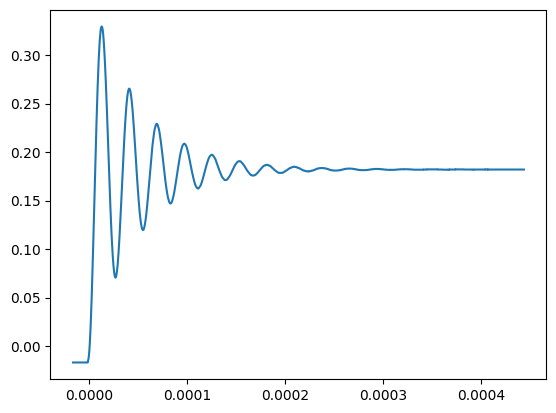

In [22]:
plt.plot(
    under_damped['second'],
    under_damped['Volt2']
)

In [23]:
ud_data = under_damped.query('second > 0')

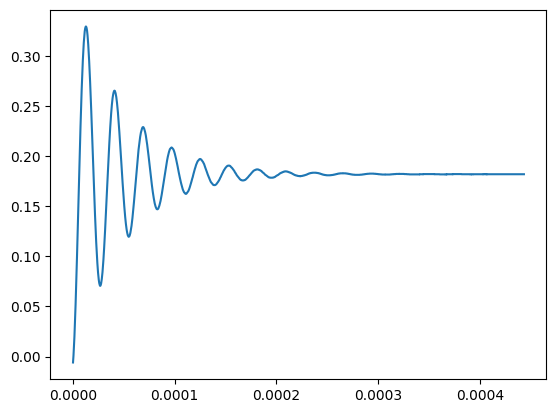

In [24]:
plt.plot(
    ud_data['second'],
    ud_data['Volt2']
)
    

228675.97854991013 5.834935223523401 0.18241431899104213 489.4734903062107
[9.40649157e+01 2.66946901e-02 9.91378835e-05 1.02852745e+08]


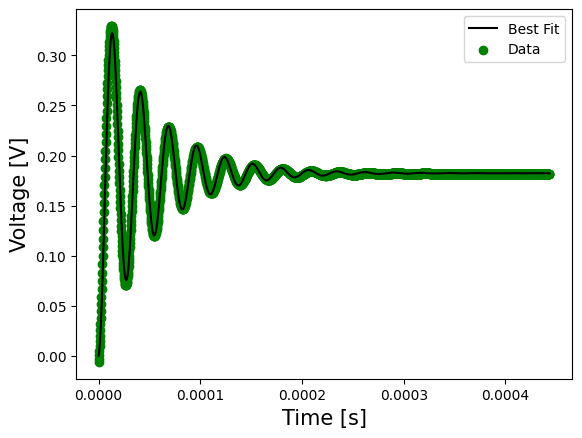

In [43]:
time = ud_data['second']
voltage = ud_data['Volt2']

def ud_model(t, omega0, Q, V_s, tau):
    exponential = np.exp(- omega0 / (2 * Q) * t) 
    omega = omega0 * np.sqrt(1 - (1 / (2 * Q))**2)
    return V_s * (1 - (exponential * np.cos(omega * t)) - (1 / (2 * tau * omega)) * exponential * np.sin(omega * t))

# NOTE: Curve fitting was terrible without initial guesses
popt, pcov = curve_fit(
    ud_model, 
    time, 
    voltage,
    # p0=[221370, 5, 0.19, 3.7734149855907775e-05]
    p0=[221370, 8.353595512, 0.19, 3.7734149855907775e-05]
) 

print(*popt)
print(np.sqrt(np.diag(pcov)))

plt.plot(time, ud_model(time, *popt), c='black', label='Best Fit')
plt.scatter(time, voltage, label='Data', color='green')
plt.legend()
plt.ylabel("Voltage [V]", fontsize=fontsize)
plt.xlabel('Time [s]', fontsize=fontsize)
plt.savefig('../tex/figures/part3_underdamped_voltage_vs_time.png', bbox_inches='tight')

### Overdamped Circuit

For the overdamped circuit $(R/2L)^2 > 1/LC$

We want to model the equation, 
$$V_{out} = V_s \left[1 - e^{-\frac{\omega_0 t}{2Q}} \cosh(\eta t) - \frac{R}{2 L \eta} e^{-\frac{\omega_0 t}{2Q}} \sinh(\eta t) \right]$$ where $$\eta = \frac{\omega_0}{2Q} \sqrt{1 - 4 Q^2}$$

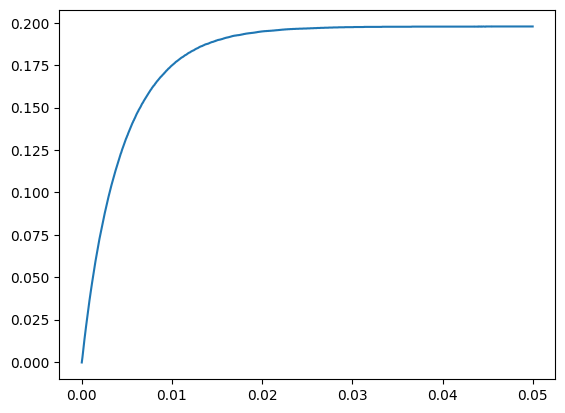

In [31]:
oc = pd.read_csv('../data/scope_11.csv')
oc_updated = oc.query('`second` > 0 and `second` < 0.05')
time = oc_updated['second'] 
v_in = oc_updated['Volt1'] 
v_out = oc_updated['Volt2']
plt.plot(time, v_out)

In [32]:
old_C = 7.12e-6

old_Q = 1 / np.sqrt(0.02095 * 7.12e-6)
old_Q

np.float64(2589.214255930634)

c:\Users\devkh\anaconda3\envs\xrbenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\devkh\anaconda3\envs\xrbenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in cosh
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\devkh\anaconda3\envs\xrbenv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in sinh
  result = getattr(ufunc, method)(*inputs, **kwargs)


343.9644200232883 0.4400694034310505 0.19775155265799718 0.0033573033189905174
[1.28287422e+00 6.69503777e-04 3.39872391e-06 4.36604764e-05]


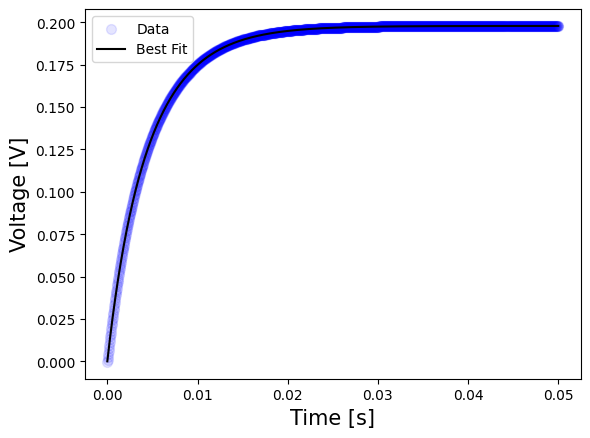

In [35]:
def model_oc(time, omega0, Q, V_s, tau):
    eta = omega0 / (2 * Q) * np.sqrt(1 - 4 * Q**2)
    exponential = np.exp(- (omega0 * time)/ (2 * Q))
    return V_s * (1 - exponential * np.cosh(eta * time) - (1/ (2 * tau * eta) * exponential * np.sinh(eta * time)))

popt, pcov = curve_fit(
    model_oc, 
    time, 
    v_out,
    p0=[2589, 0.1, 0.2, 3.77e-5]
)

print(*popt)
print(np.sqrt(np.diag(pcov)))

plt.scatter(time, v_out, s=50, alpha=0.1, label='Data', color='blue')
plt.plot(time, model_oc(time, *popt), c='black', label='Best Fit')
plt.legend()
plt.xlabel('Time [s]', fontsize=fontsize)
plt.ylabel('Voltage [V]', fontsize=fontsize)
plt.savefig('../tex/figures/part3_overdamped_voltage_vs_time', bbox_inches='tight')

# 4. RLC series circuit: frequency response

In [36]:
fr = pd.read_csv('../data/part-4-frequency-response.txt', delimiter='\t')
fr = fr.sort_values(by='f (Hz)').reset_index(drop=True)
fr

,f (Hz),df (Hz),Vin (mV),dVin (mV),Vout (mV),dVout (mV),phase (degrees),dphase (degrees),gain,dgain
0,500.0,1,200.3,0.1,200,1,0.6,0.1,0.998502,0.005017
1,2000.0,1,200.2,0.1,200,1,0.9,0.1,0.999001,0.005020
2,5000.0,1,200.2,0.1,203,1,1.0,0.1,1.013986,0.005021
3,8000.0,1,200.2,0.1,209,1,2.3,0.1,1.043956,0.005022
4,10000.0,1,200.1,0.1,217,1,2.8,0.1,1.084458,0.005027
...,...,...,...,...,...,...,...,...,...,...
83,80000.0,1,199.9,0.1,48,1,174.0,0.1,0.240120,0.005004
84,85000.0,1,199.9,0.1,40,1,175.0,0.1,0.200100,0.005004
85,90000.0,1,199.0,0.1,40,1,176.0,0.1,0.201005,0.005026
86,95000.0,1,200.1,0.1,31,1,176.0,0.1,0.154923,0.004998


So, $$Q = \frac{f_0}{\delta f}$$  where $$\delta f = \frac{R}{4\pi L}$$

35644.08272661923 -5.801830907028277
[5.05525008 0.01834609]


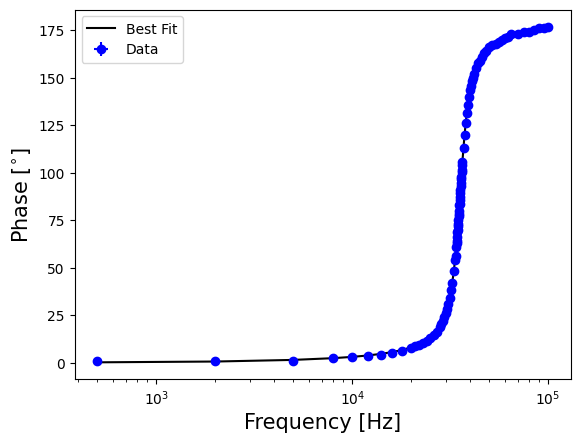

In [ ]:
phase = fr['phase (degrees)']
frequency = fr['f (Hz)']

def phase_model(freq, f0, Q):
    # Numerator and Denominator of the transfer function phase
    num = freq / (f0 * Q)
    den = 1 - (freq / f0)**2
    # arctan2(y, x) returns values in (-pi, pi]
    return - np.arctan2(num, den) * 180 / np.pi

popt, pcov = curve_fit(phase_model, frequency, phase)
print(*popt)
print(np.sqrt(np.diag(pcov)))

plt.plot(frequency, phase_model(frequency, *popt), label='Best Fit', c='k')
plt.errorbar(
    frequency, 
    phase,
    xerr=fr['df (Hz)'],
    yerr=fr['dphase (degrees)'],
    label='Data',
    fmt='o',
    color='blue'
)
plt.xscale('log')
plt.legend()
plt.xlabel('Frequency [Hz]', fontsize=fontsize)
plt.ylabel(r'Phase [$^{\circ}$]', fontsize=fontsize)
plt.savefig('../tex/figures/part4_phase_vs_freq.png', bbox_inches='tight')

[-3.56458515e+04  5.78154051e+00]
[4.19103939e+00 2.83885482e-03]


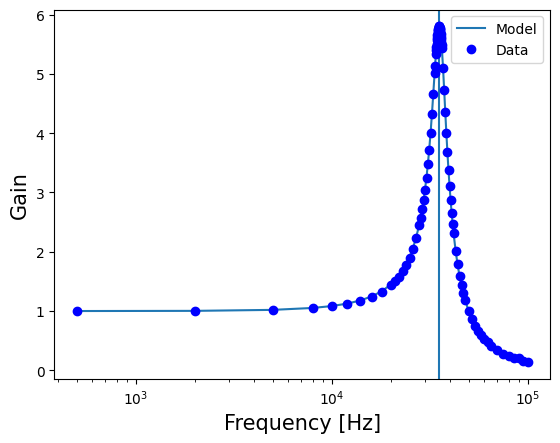

In [ ]:
gain = fr['gain']

def gain_model_func(f, f0, Q):
    return 1 / np.sqrt((1 - (f**2 / f0**2))**2 + f**2 / (f0 * Q)**2)
    
popt, pcov = curve_fit(gain_model_func, frequency, gain)
perr = np.sqrt(np.diag(pcov))

print(popt)
perr = np.sqrt(np.diag(pcov))
print(perr)

# plt.scatter(frequency, gain, label='Data')
plt.errorbar(
    frequency, 
    gain,
    # xerr=fr['df (Hz)'],
    # yerr=fr['dgain '],
    label='Data',
    fmt='o',
    color='blue'
)
plt.plot(frequency, gain_model_func(frequency, *popt), label='Model')
plt.xscale('log')
plt.xlabel('Frequency [Hz]', fontsize=fontsize)
plt.ylabel('Gain', fontsize=fontsize)
plt.legend()
plt.savefig('../tex/figures/part4_gain_vs_freq.png', bbox_inches='tight')